# ex32. PyTorch FashionMNIST 분류

이번 예제에서는 `torchvision.datasets.FashionMNIST` 데이터를 사용해서 의류 이미지를 10개 클래스로 분류하는 CNN 모델을 만든다.

학습 흐름은 다음과 같다.

1. Mac M2에서 사용할 장치(`mps` 또는 `cpu`) 확인
2. FashionMNIST 데이터셋 다운로드 및 전처리
3. `DataLoader`로 미니배치 구성
4. CNN 모델 정의
5. 학습, 평가, 예측 결과 확인
6. 학습한 모델 저장


## Mac M2 실행 환경

Apple Silicon(M1/M2/M3)에서는 PyTorch가 Metal 기반 `mps` 장치를 지원한다. 노트북 안의 코드는 `mps` 사용 가능 여부를 자동으로 확인하고, 사용할 수 없으면 `cpu`로 실행한다.

필요 패키지가 없다면 터미널에서 아래 명령을 먼저 실행한다.

```bash
python -m pip install torch torchvision matplotlib
```

Jupyter 커널이 별도 가상환경(`data-env` 등)을 사용한다면, 해당 환경을 활성화한 뒤 설치해야 한다.


In [6]:
import platform
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python platform: {platform.platform()}")
print(f"PyTorch version: {torch.__version__}")

Python platform: macOS-26.3.1-arm64-arm-64bit
PyTorch version: 2.12.0


## 장치 선택

- `mps`: Mac M2 GPU 사용
- `cuda`: NVIDIA GPU 사용
- `cpu`: 위 장치를 사용할 수 없을 때 기본 CPU 사용


In [7]:
if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"사용 장치: {device}")

사용 장치: mps


## 데이터 전처리

FashionMNIST 이미지는 흑백 28x28 크기이다.

`transforms.ToTensor()`는 이미지를 `[0, 1]` 범위의 텐서로 바꾸고, `transforms.Normalize()`는 학습이 조금 더 안정적으로 진행되도록 값을 정규화한다.


In [8]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

data_root = "./data"

train_dataset = datasets.FashionMNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

print(f"학습 데이터: {len(train_dataset):,}개")
print(f"테스트 데이터: {len(test_dataset):,}개")

학습 데이터: 60,000개
테스트 데이터: 10,000개


## DataLoader 구성

`DataLoader`는 데이터를 미니배치 단위로 나누어 모델에 넣어준다. Mac/Jupyter 환경에서는 `num_workers=0`이 가장 안정적이라 여기서는 0으로 둔다.


In [9]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

images, labels = next(iter(train_loader))
print(f"이미지 배치 shape: {images.shape}")
print(f"라벨 배치 shape: {labels.shape}")

이미지 배치 shape: torch.Size([64, 1, 28, 28])
라벨 배치 shape: torch.Size([64])


## 데이터 샘플 확인

정규화된 이미지를 화면에 보여주기 위해 다시 `[0, 1]` 범위로 되돌린 뒤 출력한다.


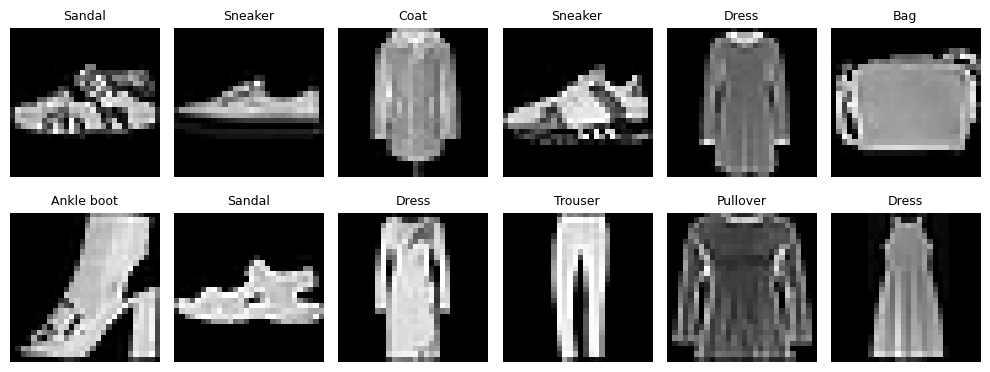

In [10]:
def denormalize(image):
    return image * 0.5 + 0.5

plt.figure(figsize=(10, 4))
for idx in range(12):
    image = denormalize(images[idx]).squeeze()
    label = labels[idx].item()

    plt.subplot(2, 6, idx + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_names[label], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## CNN 모델 설계

이미지는 2차원 구조를 가지고 있으므로 완전연결층만 사용하는 것보다 합성곱 신경망(CNN)이 더 적합하다.

이 모델은 다음 구조를 사용한다.

1. 합성곱 + ReLU + MaxPool
2. 합성곱 + ReLU + MaxPool
3. Flatten
4. 완전연결층으로 10개 클래스 점수 출력


In [11]:
class FashionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


if "device" not in globals():
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"사용 장치: {device}")

model = FashionCNN().to(device)
print(model)

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 손실 함수와 옵티마이저

다중 분류 문제이므로 손실 함수는 `CrossEntropyLoss`를 사용한다. 옵티마이저는 Adam을 사용한다.


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 학습 함수와 평가 함수

학습 함수에서는 `model.train()`을 사용하고, 평가 함수에서는 `model.eval()`과 `torch.no_grad()`를 사용한다. 평가 시에는 기울기를 계산하지 않아 메모리와 시간이 절약된다.


In [13]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

## 모델 학습

처음 실습할 때는 `epochs=3` 정도로 빠르게 확인하고, 정확도를 더 올리고 싶으면 5~10으로 늘려본다. M2의 `mps`를 사용하면 CPU보다 빠르게 학습할 수 있다.


In [14]:
epochs = 3
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch}/{epochs} | "
        f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
        f"test loss: {test_loss:.4f}, test acc: {test_acc:.4f}"
    )

Epoch 1/3 | train loss: 0.4737, train acc: 0.8298 | test loss: 0.3255, test acc: 0.8804
Epoch 2/3 | train loss: 0.3023, train acc: 0.8912 | test loss: 0.2825, test acc: 0.8979
Epoch 3/3 | train loss: 0.2539, train acc: 0.9084 | test loss: 0.2562, test acc: 0.9066


## 학습 결과 시각화

손실은 낮아질수록 좋고, 정확도는 높아질수록 좋다. 학습 정확도와 테스트 정확도의 차이가 너무 커지면 과적합을 의심할 수 있다.


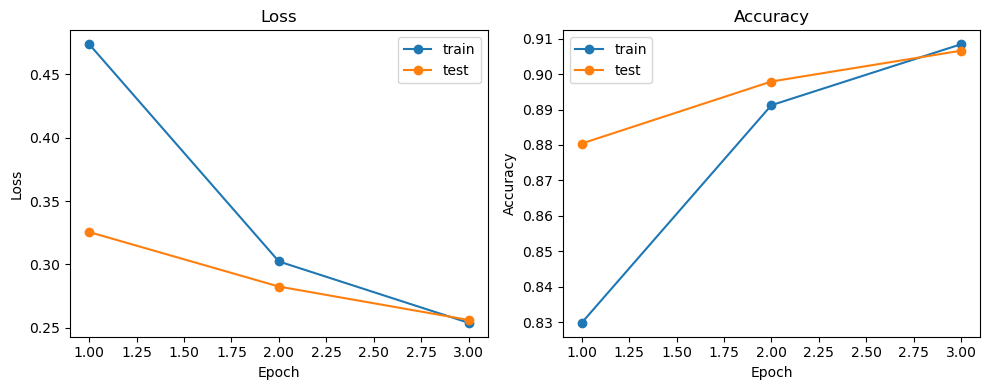

In [15]:
epoch_range = range(1, epochs + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_range, history["train_loss"], marker="o", label="train")
plt.plot(epoch_range, history["test_loss"], marker="o", label="test")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_range, history["train_acc"], marker="o", label="train")
plt.plot(epoch_range, history["test_acc"], marker="o", label="test")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 예측 결과 확인

테스트 이미지 일부를 가져와서 모델의 예측값과 실제 정답을 비교한다. 초록색 제목은 정답, 빨간색 제목은 오답이다.


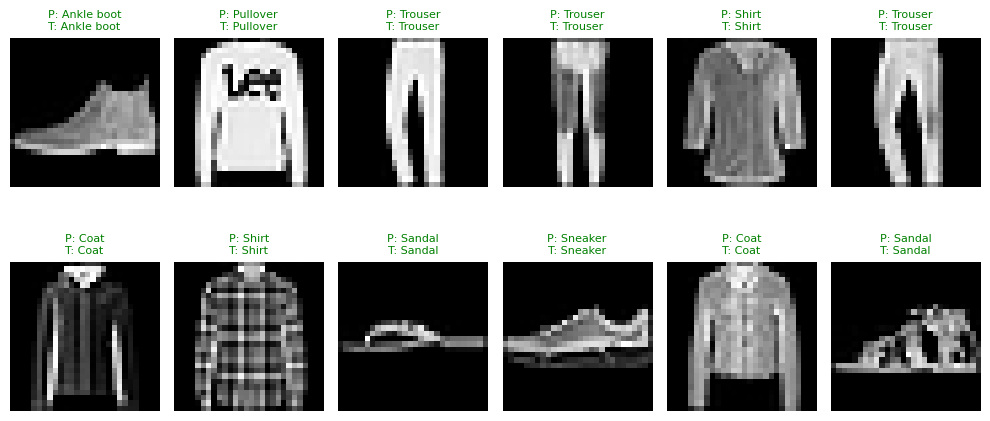

In [16]:
@torch.no_grad()
def predict_batch(model, images, device):
    model.eval()
    outputs = model(images.to(device))
    return outputs.argmax(dim=1).cpu()


test_images, test_labels = next(iter(test_loader))
predictions = predict_batch(model, test_images, device)

plt.figure(figsize=(10, 5))
for idx in range(12):
    image = denormalize(test_images[idx]).squeeze()
    pred = predictions[idx].item()
    true = test_labels[idx].item()
    title_color = "green" if pred == true else "red"

    plt.subplot(2, 6, idx + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"P: {class_names[pred]}\nT: {class_names[true]}",
        color=title_color,
        fontsize=8,
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## 혼동 행렬 확인

혼동 행렬은 어떤 클래스를 어떤 클래스로 많이 헷갈리는지 보여준다. 행은 실제 정답, 열은 모델 예측이다.


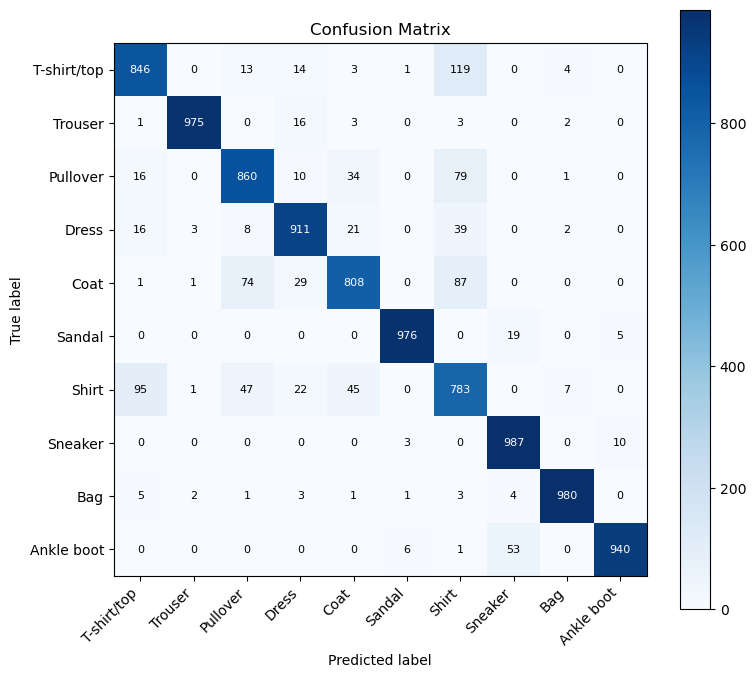

In [17]:
@torch.no_grad()
def make_confusion_matrix(model, data_loader, device, num_classes=10):
    model.eval()
    matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

    for images, labels in data_loader:
        outputs = model(images.to(device))
        predictions = outputs.argmax(dim=1).cpu()

        for true, pred in zip(labels, predictions):
            matrix[true.item(), pred.item()] += 1

    return matrix


confusion = make_confusion_matrix(model, test_loader, device)

plt.figure(figsize=(8, 7))
plt.imshow(confusion, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.colorbar()

for row in range(10):
    for col in range(10):
        value = confusion[row, col].item()
        color = "white" if value > confusion.max().item() * 0.6 else "black"
        plt.text(col, row, value, ha="center", va="center", color=color, fontsize=8)

plt.tight_layout()
plt.show()

## 모델 저장

학습이 끝난 모델의 가중치를 저장해두면 다음에 다시 학습하지 않고 불러와서 사용할 수 있다.


In [18]:
save_path = "fashion_mnist_cnn.pth"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "test_accuracy": history["test_acc"][-1],
    },
    save_path,
)

print(f"모델 저장 완료: {save_path}")

모델 저장 완료: fashion_mnist_cnn.pth


## 저장한 모델 불러오기

저장한 모델을 사용할 때는 같은 모델 클래스를 만든 뒤 `load_state_dict()`로 가중치를 넣어준다.


In [19]:
loaded_model = FashionCNN().to(device)
checkpoint = torch.load(save_path, map_location=device)
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()

print(f"불러온 모델의 테스트 정확도: {checkpoint['test_accuracy']:.4f}")

불러온 모델의 테스트 정확도: 0.9066


## 정리

이번 예제에서 확인한 핵심은 다음과 같다.

- FashionMNIST는 28x28 흑백 이미지 분류 데이터셋이다.
- Mac M2에서는 `mps` 장치를 사용할 수 있으면 GPU 가속으로 학습할 수 있다.
- CNN은 이미지의 공간적 특징을 학습하는 데 적합하다.
- `CrossEntropyLoss`는 다중 클래스 분류에서 자주 사용하는 손실 함수이다.
- 학습 후에는 테스트 정확도, 샘플 예측, 혼동 행렬로 모델 성능을 확인할 수 있다.
